In [113]:
import torch
import numpy as np
import os
import xarray as xr 
import matplotlib.pyplot as plt 


In [ ]:
preds_dir = '../preds/'
dataset_dir = '../data/'

SCALING_FACTOR = 8
TEST_YEAR = 1984
TRAIN_START = '1980-01-01'
TRAIN_END = '1982-12-31'

In [115]:
def load_dataset(data, start, end, patch_size):
    dataset = xr.open_dataset(data).sel(valid_time=slice(start, end)).isel(
        longitude=slice(0, patch_size), latitude=slice(0, patch_size))
    return dataset

def normalize_data(data, custom_scale = None):
    returned_scale = {}
    for var in data:
        
        if custom_scale and var in custom_scale:
            min_val = custom_scale[var]['min']
            max_val = custom_scale[var]['max']
        else:
            min_val = data[var].values.min()
            max_val = data[var].values.max()
            
            returned_scale[var] = {'min': min_val, 'max': max_val}
            
            
        data[var] = (data[var] - min_val) / (max_val - min_val)
        
        
    return data, returned_scale


def average_pooling(data, scale, to_int=False):
    new_h, new_w = data.shape[0] // scale, data.shape[1] // scale
    data = data.reshape(new_h, scale, new_w, scale).mean(axis=(1, 3))
    if to_int:
        data = np.uint8(data)
    return data

def get_original_wind_speed(data, scale):
    u_min = scale['u10']['min'].item()
    u_max = scale['u10']['max'].item()
    v_min = scale['v10']['min'].item()
    v_max = scale['v10']['max'].item()
    
    norm_u = data[:,0,:,:]
    norm_v = data[:,1,:,:]
    
    u = norm_u * (u_max - u_min) + u_min
    v = norm_v * (v_max - v_min) + v_min


    return torch.sqrt(u**2 + v**2)


def mse(pred, target):
    return ((pred - target) ** 2).mean()
def mae(pred, target):
    return (np.abs(pred - target)).mean()


def get_metrics(preds, target):
    if isinstance(preds, torch.Tensor):
        preds = preds.numpy()
    mse_val = mse(preds, target)
    mae_val = mae(preds, target)
    return mse_val, mae_val



In [116]:
files = os.listdir(preds_dir)
print(files)

['EDSR_1984_8x.pt', 'output_1984_4x.pt', 'EDSR_1984_4x.pt', 'EDSR_1984_2x.pt', 'output_1984_2x.pt', 'baseline_1984_2x.pt', 'baseline_1984_4x.pt', 'baseline_1984_8x.pt']


# Ground Truth

In [117]:
def get_ground_truth_ws(data_dir, train_start,train_end, test_year):
    dataset = load_dataset(data_dir, start=train_start, end=f'{test_year}-12-31', patch_size=32)
    train_split = dataset.sel(valid_time=slice(train_start, train_end))
    test_split = dataset.sel(valid_time=slice(f'{test_year}-01-01', f'{test_year}-12-31'))
    _, scale = normalize_data(train_split)
    gt_ws = np.sqrt(test_split['u10'].values**2 + test_split['v10'].values**2)
    return test_split, gt_ws, scale

eval_split, ground_truth_wind_speeds, scale = get_ground_truth_ws(data_dir=dataset_dir + 'era5_training.nc',
                                                                    train_start=TRAIN_START,
                                                                    train_end=TRAIN_END,
                                                                    test_year=TEST_YEAR)


# Low res input

In [118]:
def get_low_res_ws(test_data, scaling_factor):
    u10, v10 = [], []
    for i in range(test_data['u10'].shape[0]):
        u10.append(average_pooling(test_data['u10'][i].values, scaling_factor, False))
        v10.append(average_pooling(test_data['v10'][i].values, scaling_factor, False))
    u10 = np.array(u10)
    v10 = np.array(v10)
    lr_ws = np.sqrt(u10**2 + v10**2)
    return lr_ws

lr_wind_speeds = get_low_res_ws(eval_split, SCALING_FACTOR)


# Model Output

In [119]:
def get_wind_speed_fields(files_dir, scaling_factor, year, normalization_scale,lr_ws, gt_ws):
    files = os.listdir(files_dir)
    ws_fields = [lr_ws, gt_ws]
    names = ["LR Input", "HR Ground Truth"]
   
    for file in files:
        if not file.endswith(f'{scaling_factor}x.pt'):
            continue
        field = torch.load(files_dir + file, weights_only=False)
        print("Current file: ", file)   
        
        if file == f'baseline_{year}_{scaling_factor}x.pt':
            baseline = get_original_wind_speed(field, normalization_scale)
            names.append("Bicubic Interpolation")
            ws_fields.append(baseline)
            
        elif file == f'EDSR_{year}_{scaling_factor}x.pt':
            names.append("EDSR")
            edsr = get_original_wind_speed(field, normalization_scale)
            ws_fields.append(edsr)
    return ws_fields, names


# Compare 


Current file:  EDSR_1984_2x.pt
Current file:  output_1984_2x.pt
Current file:  baseline_1984_2x.pt
887


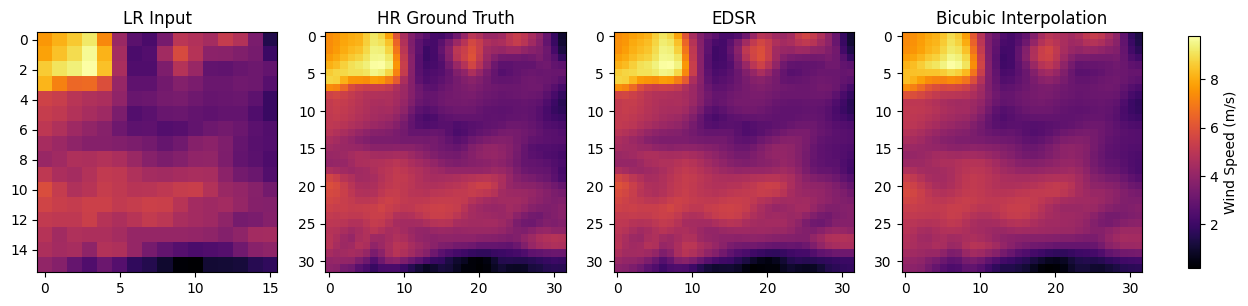

In [120]:
def plot_comparison(fields, names, index):
    assert len(fields) == len(names)
    fig, ax = plt.subplots(1, len(names), figsize=(15, 6))
    fields = [field[index] for field in fields]
    for i, field in enumerate(fields):
        if names[i] == "HR Ground Truth":
            im = ax[i].imshow(field, cmap='inferno')
        else:
            ax[i].imshow(field, cmap='inferno')
        ax[i].set_title(names[i])
        #ax[i].axis('off')
    cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.01, pad=0.04)
    cbar.set_label('Wind Speed (m/s)')
    
    plt.show()

ws_fields, names = get_wind_speed_fields(files_dir=preds_dir, scaling_factor=SCALING_FACTOR, year=TEST_YEAR, 
                                        normalization_scale=scale, lr_ws=lr_wind_speeds, 
                                        gt_ws=ground_truth_wind_speeds)
index = np.random.randint(0, len(ground_truth_wind_speeds))
print(index)
plot_comparison(ws_fields, names, index)

# 626


In [121]:
print(np.mean(ground_truth_wind_speeds))
print(np.std(ground_truth_wind_speeds))
print(np.min(ground_truth_wind_speeds))
print(np.max(ground_truth_wind_speeds))

3.7423608
2.4426157
0.0011898181
23.356188


In [122]:
# Metrics in original range
edsr, baseline = ws_fields[names.index("EDSR")], ws_fields[names.index("Bicubic Interpolation")]
mse_edsr, mae_edsr = get_metrics(edsr, ground_truth_wind_speeds)
mse_baseline, mae_baseline = get_metrics(baseline, ground_truth_wind_speeds)
print(f"EDSR: MSE: {mse_edsr:.4f}, MAE: {mae_edsr:.4f}")
print(f"Baseline: MSE: {mse_baseline:.4f}, MAE: {mae_baseline:.4f}")


EDSR: MSE: 0.0053, MAE: 0.0503
Baseline: MSE: 0.0270, MAE: 0.1096


# Compare Metrics over years

In [123]:
def get_metrics_over_time(years):
    mses = {'EDSR': [], 'Bicubic': []}
    maes = {'EDSR': [], 'Bicubic': []}
    for year in years:
        eval_split, ground_truth_wind_speeds, scale = get_ground_truth_ws(data_dir=dataset_dir + 'era5_training.nc',
                                                                    train_start=TRAIN_START,
                                                                    train_end=TRAIN_END,
                                                                    test_year=year)
        lr_wind_speeds = get_low_res_ws(eval_split, SCALING_FACTOR)
        ws_fields, names = get_wind_speed_fields(files_dir=preds_dir, scaling_factor=SCALING_FACTOR, year=year, 
                                        normalization_scale=scale, lr_ws=lr_wind_speeds, 
                                        gt_ws=ground_truth_wind_speeds)
        edsr = ws_fields[names.index('EDSR')]
        baseline = ws_fields[names.index('Bicubic Interpolation')]
        mse_edsr, mae_edsr = get_metrics(edsr, ground_truth_wind_speeds)
        mse_baseline, mae_baseline = get_metrics(baseline, ground_truth_wind_speeds)
        mses['EDSR'].append(mse_edsr)
        mses['Bicubic'].append(mse_baseline)
        maes['EDSR'].append(mae_edsr)
        maes['Bicubic'].append(mae_baseline)
        print(f"Year: {year}")
        print(f"EDSR: MSE: {mse_edsr:.4f}, MAE: {mae_edsr:.4f}")
        print(f"Bicubic: MSE: {mse_baseline:.4f}, MAE: {mae_baseline:.4f}")
    return mses, maes


def plot_metrics_over_time(years, mses, maes):
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))
    for model in mses:
        ax[0].plot(years, mses[model], label=model)
    ax[0].set_title('MSE')
    ax[0].set_xlabel('Year')
    ax[0].set_ylabel('MSE')
    ax[0].legend()
    
    for model in maes:
        ax[1].plot(years, maes[model], label=model)
    ax[1].set_title('MAE')
    ax[1].set_xlabel('Year')
    ax[1].set_ylabel('MAE')
    ax[1].legend()
    plt.title('Metrics over time')
    plt.grid()
    plt.show()